## Chatbot with Profile Schema & LongTerm Memory and HOt-Path writing

### Review:
- we built a chatbot with both chekpointer (withing thread) session based memory and store (across thread) long term mmeory agents previously
- agent saved semantic memory(facts and information or general knowlege ) about the user in the store
- we learnt to define namespace and use get and put methods to interact with the store.
- get - get memory
- put - write to the store
- memory was stored `in the hot path` as user was chatting or interactivng with it

### Goal: Chatbot storeing memory in a sturctured manner
- previously we stored the memory as a string seperated by comma
- In practice , memory must have structure which makes them easy to access and use
### Objective:
- Build a chatbot that saves semantic memory of the user in a **single user profile.**
- use **library and trustcall** to update the schema with new information

In [2]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

#Load lang graph tracing api
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

In [5]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [106]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-2.5-flash-lite" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

'I am a large language model, trained by Google. I do not have access to real-time information, including the current date.'

## Profile Schema
-Python has many different types for **structured data, such as TypedDict, Dictionaries, JSON, and Pydantic.**
- Use TypeDict for structured output

#### You are creating an instance of the UserProfile type.

✔ A type = the blueprint
UserProfile (your TypedDict) defines:
- what fields exist
- what types those fields must have
- It’s like a schema.

✔ An instance = a real object created from that blueprint
- user_profile is the actual data object that follows the schema.

TypedDict : “Here is what a user profile should look like.”

Instance : “Here is one actual user profile.”

TypedDict instances are used for:
- state objects
- memory stores
- tool inputs
- structured outputs
- agent context
They help ensure your data is predictable and type‑safe.

In [91]:
from typing_extensions import TypedDict , List


# create a class blue print schema for user profile
class Userprofile(TypedDict, total =False):
    user_name : str
    age:int
    interests:List[str] # list of user interests
    additional_info: dict[str, str]   # <— catch‑all bucket # in case of additional information

    
# create an instance of **Userprofile** with real objects
user_profile : Userprofile = {
    "user_name" : 'Diya',
    "age":40,
    "interests": ["Loves reading", "gardening", "Swimming"]
}
user_profile

{'user_name': 'Diya',
 'age': 40,
 'interests': ['Loves reading', 'gardening', 'Swimming']}

## update the store schema
- Use method PUT
- 

In [92]:
# initialize in memory store
from langgraph.store.memory import InMemoryStore
store_memory = InMemoryStore()

# set up namespace for store
user_id ="1"
namespace = ("memory" , user_id)

# set key and value
key = "user_profile"
value = user_profile # schema instance

# update the store
store_memory.put(namespace , key , value)

### retrive memory:
1. use GET method
2. search the store to retrive values

In [93]:
# using get method
memory = store_memory.get(namespace , key)
memory

Item(namespace=['memory', '1'], key='user_profile', value={'user_name': 'Diya', 'age': 40, 'interests': ['Loves reading', 'gardening', 'Swimming']}, created_at='2026-06-04T02:07:51.715696+00:00', updated_at='2026-06-04T02:07:51.715696+00:00')

In [94]:
memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_profile',
 'value': {'user_name': 'Diya',
  'age': 40,
  'interests': ['Loves reading', 'gardening', 'Swimming']},
 'created_at': '2026-06-04T02:07:51.715696+00:00',
 'updated_at': '2026-06-04T02:07:51.715696+00:00'}

In [95]:
# search the store
search_memory = store_memory.search(namespace)
search_memory

[Item(namespace=['memory', '1'], key='user_profile', value={'user_name': 'Diya', 'age': 40, 'interests': ['Loves reading', 'gardening', 'Swimming']}, created_at='2026-06-04T02:07:51.715696+00:00', updated_at='2026-06-04T02:07:51.715696+00:00', score=None)]

In [96]:
search_memory[-1].dict()

{'namespace': ['memory', '1'],
 'key': 'user_profile',
 'value': {'user_name': 'Diya',
  'age': 40,
  'interests': ['Loves reading', 'gardening', 'Swimming']},
 'created_at': '2026-06-04T02:07:51.715696+00:00',
 'updated_at': '2026-06-04T02:07:51.715696+00:00',
 'score': None}

## structured output:
- We can have LLMs generate structured output by providing the schema to it . 
- LLM parses the output in a similar structure to provided schema

### Objective:
- pass the user_profile schema created into the LLM `with_structured_output` method.
- get structured response confirming to the schema

In [97]:
# create chat messages
from langchain_core.messages import HumanMessage ,AIMessage ,SystemMessage

structed_ouput_model = llm.with_structured_output(Userprofile)
response = structed_ouput_model.invoke("Hi, Im Divya. I love reading books, cooking and gradening")
response

{'user_name': 'Divya',
 'age': 30,
 'interests': ['reading books', 'cooking', 'gardening'],
 'additional_info': {}}

In [98]:
sys_info = [SystemMessage(content='''You are a profile generator. Extract user information for profiling. 
                                    Use only the information provided. Do not assume or invent information. Do not miss out information''')]
user_info = [HumanMessage(content="Hi , I love riding bike. I was thinking of going trecking. I love eating out and travelling. My name Diya")]
response1 = structed_ouput_model.invoke(sys_info + user_info)
response1

{'user_name': 'Diya',
 'age': 0,
 'interests': ['riding bike', 'trecking', 'eating out', 'travelling'],
 'additional_info': {}}

### Build a graph

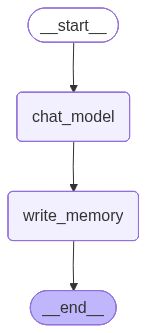

In [107]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import BaseStore
from langgraph.graph import MessagesState, StateGraph, START , END

# get runnable config to get configuration
from langchain_core.runnables import RunnableConfig


# define nodes

# chat model node
sys_inst_llm = '''You are a helpful assistant with existing memory of users. Your job is to respond to the user with accurate information. 
                     Use existing memory to personalise your response. Please follow these steps:
                     - Use only the information provided. 
                     - Do not assume or invent information. 
                     - Do not miss out information
                     - memory may be empty or doesnot exist.
                     Here is the memory : {memory}'''
def chat_model(state:MessagesState , config:RunnableConfig , store:BaseStore):
    ''' Node to respond to user queries based on the meory '''
    # get memory
    user_id = config['configurable']['user_id']
    print(f"user_id: {user_id}\n")
    namespace = ("memory" , user_id)
    key = "user_profile"
    existing_memory = store.get(namespace , key)
    print(f"existing_memory: {existing_memory}\n")
    # format memory
    if existing_memory and existing_memory.value:
        memory_value = existing_memory.value
    else:
        memory_value = "No memory exists"

    # set system instruction
    sys_prompt = SystemMessage(content=sys_inst_llm.format(memory = memory_value))
    response = llm.invoke([sys_prompt] + state['messages'])
    #print(f"response form LLM: {response}")
    # update state
    return { 'messages' : [response]}

# write to or update the memory 

sys_ins_update_memory = ''' You are a helpful profiler. You have existsing memory of the users. You extract new information from the chat messages
                        given to you. review the existing memory and merge or update it with new information. If there is a confict ,
                        use latest information. Follow the rules below:
                        1.  Do not add or invent information.
                        2. do not missout or omit information from the memory as well as chat messages. Include all the important info or facts.
                        3. in case of any additional information about the user , create an additional related field (key :value pair) 
                        in the response as type(str). 
                        4. do not repeat information.
                        Here is the existing memory : {memory}'''

def write_memory(state:MessagesState , config: RunnableConfig , store:BaseStore): 
    ''' Node to write or update the existing memory store'''
    # get existing memory
    user_id = config['configurable']['user_id']
    namespace = ("memory" , user_id)
    key = "user_profile"
    existing_memory = store.get(namespace , key)
    # format 
    if existing_memory and existing_memory.value:
        
        memory_value = existing_memory.value
    else:
        memory_value = None

    # update system instruction
    sys_write_prompt = SystemMessage(content= sys_ins_update_memory.format(memory = memory_value))

    # get sturctured output
    structured_llm = llm.with_structured_output(Userprofile)
    write_response = structured_llm.invoke([sys_write_prompt] + state['messages'])
    print("write_response: ", write_response)
    # update the store
    try:
        store.put(namespace , key , write_response)
    except Exception as e: 
        print("Error writing to the store" , e)

    
# build graph
builder = StateGraph(MessagesState)

# add nodes
builder.add_node("chat_model" , chat_model)
builder.add_node("write_memory" , write_memory)

# add flow
builder.add_edge(START , "chat_model")
builder.add_edge("chat_model", "write_memory" )
builder.add_edge("write_memory", END)

# set checkpoiter and long term memory
checkpointer = MemorySaver() # thread memory
store_memory = InMemoryStore()

# build graph
graph = builder.compile(checkpointer=checkpointer , store = store_memory)

#view
from IPython.display import Image , display
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

### invoke graph


In [108]:
# provide thread_id for session memory and user_id for long term mery
config = {"configurable" : {'thread_id' : "1" , 'user_id': "1" }}

user_msg = HumanMessage(content="My name is D, I love to write novels. In my free time I go camping  and try new foods at new hangouts.")

# invoke graph streaming
for chunk in graph.stream({'messages': [user_msg] } , config, stream_mode = "updates"):
    print(chunk)

user_id: 1

existing_memory: None

{'chat_model': {'messages': [AIMessage(content="Hi D! It's great to meet you. Writing novels sounds like a fantastic passion. I can imagine you get a lot of inspiration from your camping trips and exploring new food spots. Do you have a favorite type of novel you enjoy writing, or perhaps a type of cuisine you're most excited to try?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9067-27bc-7c21-a5e8-e2ff12b12d18-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 119, 'output_tokens': 64, 'total_tokens': 183, 'input_token_details': {'cache_read': 0}})]}}
write_response:  {'user_name': 'D', 'age': 0, 'interests': ['writing novels', 'camping', 'trying new foods', 'exploring new hangouts'], 'additional_info': {}}
{'write_memory': None}


In [101]:
state_history = graph.get_state_history(config)
type(state_history)

generator

### check the store

In [109]:
memory = store_memory.search(namespace)
memory[0].dict()

{'namespace': ['memory', '1'],
 'key': 'user_profile',
 'value': {'user_name': 'D',
  'age': 0,
  'interests': ['writing novels',
   'camping',
   'trying new foods',
   'exploring new hangouts'],
  'additional_info': {}},
 'created_at': '2026-06-04T02:12:21.135653+00:00',
 'updated_at': '2026-06-04T02:12:21.135653+00:00',
 'score': None}

In [103]:
history = [m for m in state_history]
history[0]

StateSnapshot(values={'messages': [HumanMessage(content='My name is D, I love to write novels. In my free time I go camping  and try new foods at new hangouts.', additional_kwargs={}, response_metadata={}, id='c39c7d62-f049-4620-8f7a-a8712cfe697f'), AIMessage(content="Hello D! It's great to meet you.\n\nI've noted that you love to write novels, and in your free time, you enjoy going camping and trying new foods at new hangouts.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9064-7805-7ef1-8e9e-b447c7e4450c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 119, 'output_tokens': 140, 'total_tokens': 259, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 98}})]}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15fba6-95d8-6c12-8002-66b816b20f87'}}, metadata={'source

### continue the conversation

In [110]:
user_msg2 = HumanMessage(content="I live in state turn, tx. I'm looking for a new hobby. I love Biryani now. What restaurants in Dallas serve the best biriyani?")
# invoke graph streaming
for chunk in graph.stream({'messages': [user_msg2] } , config, stream_mode = "updates"):
    print(chunk)

user_id: 1

existing_memory: Item(namespace=['memory', '1'], key='user_profile', value={'user_name': 'D', 'age': 0, 'interests': ['writing novels', 'camping', 'trying new foods', 'exploring new hangouts'], 'additional_info': {}}, created_at='2026-06-04T02:12:21.135653+00:00', updated_at='2026-06-04T02:12:21.135653+00:00')

{'chat_model': {'messages': [AIMessage(content="I can help you find some great biryani spots in Dallas! Since you're looking for a new hobby and enjoy trying new foods, exploring different biryani restaurants could be a fun adventure.\n\nBased on popular opinion, here are a few highly-rated restaurants in Dallas that are known for their delicious biryani:\n\n*   **Paradise Biryani Point:** This is a very popular choice and often cited as a go-to for authentic biryani.\n*   **Biryani House:** Another well-regarded spot that many people rave about for its flavorful biryani.\n*   **Desi Bites:** This restaurant is also frequently mentioned for its excellent biryani.\n\n

# Check store

In [112]:
memory = store_memory.get(namespace, key)
memory.value

{'user_name': 'D',
 'age': 0,
 'interests': ['writing novels',
  'camping',
  'trying new foods',
  'exploring new hangouts',
  'biryani'],
 'additional_info': {'location': 'state turn, tx', 'looking_for_hobby': 'yes'}}